# ============================================================================
# TASK 4: OPTIMIZE PORTFOLIO BASED ON FORECAST
# ============================================================================
# Business Objective:
# Use Modern Portfolio Theory to construct an optimal portfolio
# that balances risk and return for GMF Investments
# ============================================================================


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# For portfolio optimization
from scipy.optimize import minimize
from scipy.optimize import Bounds

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# ============================================================================
# STEP 2: LOAD DATA AND CALCULATE METRICS
# ============================================================================

print("=" * 70)
print("📊 LOADING DATA AND CALCULATING METRICS")
print("=" * 70)

# Load cleaned data
adj_close_df = pd.read_csv('../data/processed/adj_close_data_clean.csv', 
                           index_col=0, parse_dates=True)

print(f"Data shape: {adj_close_df.shape}")
print(f"Date range: {adj_close_df.index.min()} to {adj_close_df.index.max()}")
print(f"Assets: {adj_close_df.columns.tolist()}")

# Calculate daily returns
returns_df = adj_close_df.pct_change().dropna()

print(f"\nReturns shape: {returns_df.shape}")

# Calculate annualized returns (historical average)
annualized_returns = returns_df.mean() * 252

print("\n📊 Historical Annualized Returns:")
for asset in annualized_returns.index:
    print(f"  {asset}: {annualized_returns[asset]*100:.2f}%")

# Calculate covariance matrix (annualized)
cov_matrix = returns_df.cov() * 252

print("\n📊 Annualized Covariance Matrix:")
print(cov_matrix)

📊 LOADING DATA AND CALCULATING METRICS
Data shape: (2888, 3)
Date range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00
Assets: ['TSLA', 'BND', 'SPY']

Returns shape: (2887, 3)

📊 Historical Annualized Returns:
  TSLA: 45.42%
  BND: 2.00%
  SPY: 14.43%

📊 Annualized Covariance Matrix:
          TSLA       BND       SPY
TSLA  0.326926  0.001803  0.049820
BND   0.001803  0.002823  0.001085
SPY   0.049820  0.001085  0.031169


In [3]:
# ============================================================================
# STEP 3: PREPARE EXPECTED RETURNS
# ============================================================================
# Business Context:
# - TSLA: Use forecast from Task 3 (we have a specific view on Tesla)
# - BND and SPY: Use historical average returns (no specific forecast)
# ============================================================================

print("=" * 70)
print("📊 PREPARING EXPECTED RETURNS")
print("=" * 70)

# Option 1: Use TSLA forecast from Task 3
# Load the forecast data
try:
    forecast_df = pd.read_csv('../data/processed/tsla_forecast_1year.csv', 
                              index_col=0, parse_dates=True)
    
    # Calculate expected annual return from forecast
    start_price = adj_close_df['TSLA'].iloc[-1]
    end_price = forecast_df['Forecast'].iloc[-1]
    tsla_expected_return = (end_price / start_price) - 1
    
    print(f"\n📈 TSLA Expected Return (from Task 3 forecast):")
    print(f"   Start Price: ${start_price:.2f}")
    print(f"   Forecast End Price: ${end_price:.2f}")
    print(f"   Expected Return: {tsla_expected_return*100:.2f}%")
    
except FileNotFoundError:
    print("\n⚠️ Forecast file not found. Using historical returns for TSLA.")
    tsla_expected_return = annualized_returns['TSLA']

# Historical returns for BND and SPY
bnd_expected_return = annualized_returns['BND']
spy_expected_return = annualized_returns['SPY']

# Create expected returns array
expected_returns = np.array([tsla_expected_return, bnd_expected_return, spy_expected_return])
assets = ['TSLA', 'BND', 'SPY']

print("\n📊 Expected Returns Summary:")
print("-" * 40)
print(f"TSLA: {expected_returns[0]*100:.2f}% (from forecast)")
print(f"BND:  {expected_returns[1]*100:.2f}% (historical average)")
print(f"SPY:  {expected_returns[2]*100:.2f}% (historical average)")

📊 PREPARING EXPECTED RETURNS

📈 TSLA Expected Return (from Task 3 forecast):
   Start Price: $411.84
   Forecast End Price: $411.09
   Expected Return: -0.18%

📊 Expected Returns Summary:
----------------------------------------
TSLA: -0.18% (from forecast)
BND:  2.00% (historical average)
SPY:  14.43% (historical average)



📊 COVARIANCE MATRIX VISUALIZATION


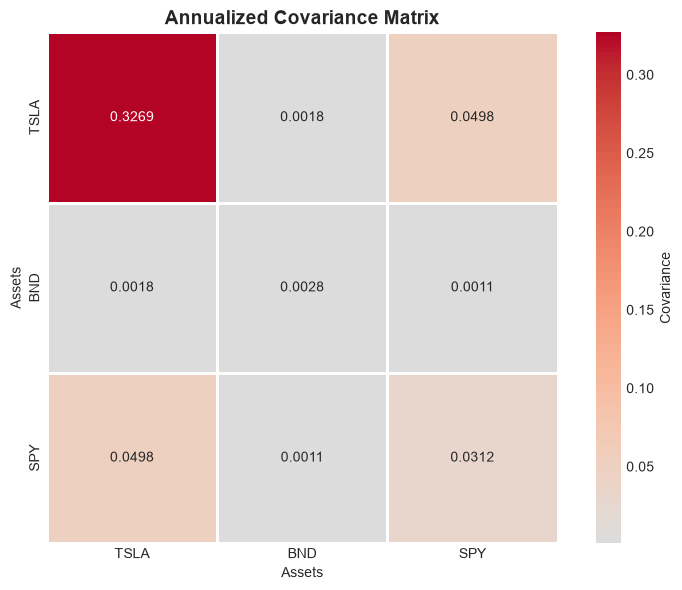

✅ Covariance matrix heatmap saved!

📊 Correlation Matrix (How assets move together):
----------------------------------------
TSLA vs BND: 0.059 (weak positive correlation)
TSLA vs SPY: 0.494 (moderate positive correlation)
BND vs SPY: 0.116 (weak positive correlation)


In [4]:
# ============================================================================
# STEP 4: VISUALIZE COVARIANCE MATRIX
# ============================================================================

print("\n" + "=" * 70)
print("📊 COVARIANCE MATRIX VISUALIZATION")
print("=" * 70)

# Create covariance matrix heatmap
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(cov_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0, 
            fmt='.4f',
            square=True,
            linewidths=1,
            cbar_kws={'label': 'Covariance'},
            ax=ax)

ax.set_title('Annualized Covariance Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Assets')
ax.set_ylabel('Assets')

plt.tight_layout()
plt.savefig('../data/processed/covariance_matrix_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Covariance matrix heatmap saved!")

# Calculate and display correlations
correlation_matrix = returns_df.corr()

print("\n📊 Correlation Matrix (How assets move together):")
print("-" * 40)
for i, asset1 in enumerate(assets):
    for j, asset2 in enumerate(assets):
        if i < j:
            corr = correlation_matrix.loc[asset1, asset2]
            strength = "strong" if abs(corr) > 0.5 else "moderate" if abs(corr) > 0.3 else "weak"
            direction = "positive" if corr > 0 else "negative"
            print(f"{asset1} vs {asset2}: {corr:.3f} ({strength} {direction} correlation)")

In [5]:
# ============================================================================
# STEP 5: DEFINE PORTFOLIO OPTIMIZATION FUNCTIONS - FIXED
# ============================================================================

print("\n" + "=" * 70)
print("📊 DEFINING OPTIMIZATION FUNCTIONS")
print("=" * 70)

def portfolio_performance(weights, expected_returns, cov_matrix):
    """
    Calculate portfolio return, volatility, and Sharpe ratio.
    
    Parameters:
    - weights: Array of portfolio weights (list or numpy array)
    - expected_returns: Array of expected returns for each asset
    - cov_matrix: Covariance matrix of asset returns
    
    Returns:
    - portfolio_return: Expected return of the portfolio
    - portfolio_volatility: Expected volatility (risk) of the portfolio
    - sharpe_ratio: Sharpe ratio of the portfolio
    """
    # Convert weights to numpy array if it's a list
    weights = np.array(weights)
    
    # Calculate portfolio return
    portfolio_return = np.sum(weights * expected_returns)
    
    # Calculate portfolio volatility
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    
    # Calculate Sharpe ratio (assuming risk-free rate = 1%)
    risk_free_rate = 0.01
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility
    
    return portfolio_return, portfolio_volatility, sharpe_ratio

def neg_sharpe(weights, expected_returns, cov_matrix):
    """
    Negative Sharpe ratio for minimization.
    """
    return -portfolio_performance(weights, expected_returns, cov_matrix)[2]

def optimize_portfolio(expected_returns, cov_matrix, target_return=None):
    """
    Find optimal portfolio weights.
    
    If target_return is None, find the maximum Sharpe ratio portfolio.
    If target_return is specified, find the minimum volatility portfolio for that return.
    """
    num_assets = len(expected_returns)
    
    # Constraints: weights sum to 1
    constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
    
    # Bounds: weights between 0 and 1 (no short selling)
    bounds = tuple((0, 1) for _ in range(num_assets))
    
    # Initial guess: equal weights
    initial_weights = np.array([1/num_assets] * num_assets)
    
    if target_return is None:
        # Maximize Sharpe ratio
        result = minimize(neg_sharpe, 
                         initial_weights, 
                         args=(expected_returns, cov_matrix),
                         method='SLSQP', 
                         bounds=bounds, 
                         constraints=constraints)
    else:
        # Minimize volatility for target return
        constraints = [constraints,
                      {'type': 'eq', 'fun': lambda x: np.sum(x * expected_returns) - target_return}]
        
        result = minimize(lambda x: np.sqrt(np.dot(x.T, np.dot(cov_matrix, x))),
                         initial_weights, 
                         method='SLSQP', 
                         bounds=bounds, 
                         constraints=constraints)
    
    return result.x

print("✅ Optimization functions defined!")


📊 DEFINING OPTIMIZATION FUNCTIONS
✅ Optimization functions defined!


In [6]:
# ============================================================================
# STEP 6: GENERATE EFFICIENT FRONTIER
# ============================================================================

print("\n" + "=" * 70)
print("📊 GENERATING EFFICIENT FRONTIER")
print("=" * 70)

# Find the maximum Sharpe ratio portfolio
optimal_weights = optimize_portfolio(expected_returns, cov_matrix)
optimal_return, optimal_volatility, optimal_sharpe = portfolio_performance(
    optimal_weights, expected_returns, cov_matrix
)

print("\n📈 Maximum Sharpe Ratio Portfolio (Tangency Portfolio):")
print("-" * 40)
for i, asset in enumerate(assets):
    print(f"  {asset}: {optimal_weights[i]*100:.1f}%")
print(f"  Expected Return: {optimal_return*100:.2f}%")
print(f"  Expected Volatility: {optimal_volatility*100:.2f}%")
print(f"  Sharpe Ratio: {optimal_sharpe:.3f}")

# Find the minimum volatility portfolio
min_vol_weights = minimize(
    lambda x: np.sqrt(np.dot(x.T, np.dot(cov_matrix, x))),
    [1/len(assets)] * len(assets),
    method='SLSQP',
    bounds=Bounds(0, 1),
    constraints={'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
).x

min_vol_return, min_vol_volatility, min_vol_sharpe = portfolio_performance(
    min_vol_weights, expected_returns, cov_matrix
)

print("\n📈 Minimum Volatility Portfolio:")
print("-" * 40)
for i, asset in enumerate(assets):
    print(f"  {asset}: {min_vol_weights[i]*100:.1f}%")
print(f"  Expected Return: {min_vol_return*100:.2f}%")
print(f"  Expected Volatility: {min_vol_volatility*100:.2f}%")
print(f"  Sharpe Ratio: {min_vol_sharpe:.3f}")

# Generate Efficient Frontier
# We'll find optimal portfolios for a range of target returns
target_returns = np.linspace(min_vol_return, expected_returns.max() * 1.2, 50)
frontier_volatilities = []
frontier_weights = []

print("\n🔄 Generating Efficient Frontier points...")
for target in target_returns:
    try:
        weights = optimize_portfolio(expected_returns, cov_matrix, target_return=target)
        ret, vol, sharpe = portfolio_performance(weights, expected_returns, cov_matrix)
        frontier_volatilities.append(vol)
        frontier_weights.append(weights)
    except:
        frontier_volatilities.append(np.nan)
        frontier_weights.append([np.nan] * len(assets))

# Remove NaN values
valid_indices = ~np.isnan(frontier_volatilities)
frontier_volatilities = np.array(frontier_volatilities)[valid_indices]
target_returns_filtered = np.array(target_returns)[valid_indices]

print(f"✅ Efficient Frontier generated with {len(frontier_volatilities)} points")


📊 GENERATING EFFICIENT FRONTIER

📈 Maximum Sharpe Ratio Portfolio (Tangency Portfolio):
----------------------------------------
  TSLA: 0.0%
  BND: 30.8%
  SPY: 69.2%
  Expected Return: 10.60%
  Expected Volatility: 12.51%
  Sharpe Ratio: 0.767

📈 Minimum Volatility Portfolio:
----------------------------------------
  TSLA: 0.0%
  BND: 94.6%
  SPY: 5.4%
  Expected Return: 2.67%
  Expected Volatility: 5.22%
  Sharpe Ratio: 0.320

🔄 Generating Efficient Frontier points...
✅ Efficient Frontier generated with 50 points



📊 VISUALIZING EFFICIENT FRONTIER


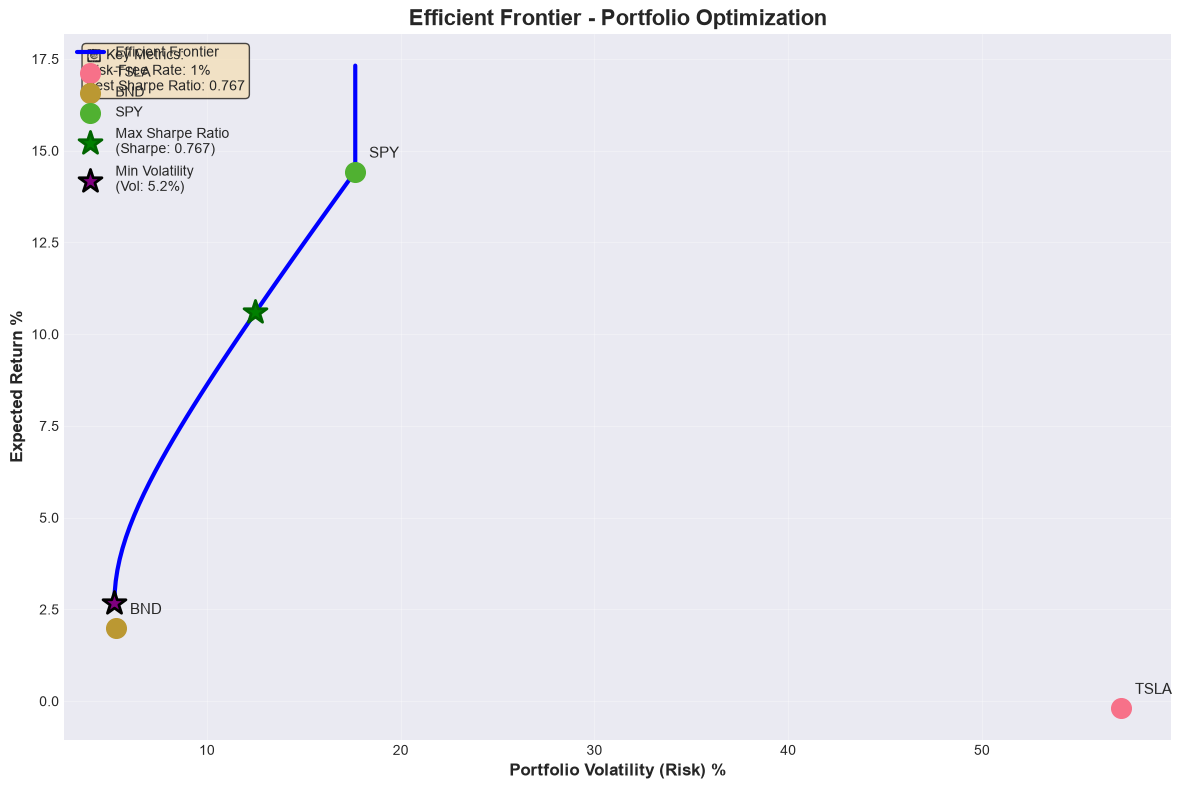

✅ Efficient Frontier visualization saved!


In [7]:
# ============================================================================
# STEP 8: VISUALIZE EFFICIENT FRONTIER
# ============================================================================

print("\n" + "=" * 70)
print("📊 VISUALIZING EFFICIENT FRONTIER")
print("=" * 70)

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# 1. Plot Efficient Frontier
ax.plot(frontier_volatilities * 100, target_returns_filtered * 100, 
        'b-', linewidth=3, label='Efficient Frontier')

# 2. Plot individual assets
asset_volatilities = np.sqrt(np.diag(cov_matrix))
for i, asset in enumerate(assets):
    ax.scatter(asset_volatilities[i] * 100, expected_returns[i] * 100, 
               s=200, marker='o', label=asset, zorder=5)
    ax.annotate(asset, 
                (asset_volatilities[i] * 100, expected_returns[i] * 100),
                xytext=(10, 10), textcoords='offset points', fontsize=11)

# 3. Plot Maximum Sharpe Ratio Portfolio (Tangency)
ax.scatter(optimal_volatility * 100, optimal_return * 100, 
           s=300, marker='*', color='green', 
           label=f'Max Sharpe Ratio\n(Sharpe: {optimal_sharpe:.3f})', 
           zorder=10, edgecolors='darkgreen', linewidths=2)

# 4. Plot Minimum Volatility Portfolio - FIXED COLOR
ax.scatter(min_vol_volatility * 100, min_vol_return * 100, 
           s=300, marker='*', color='purple', 
           label=f'Min Volatility\n(Vol: {min_vol_volatility*100:.1f}%)', 
           zorder=10, edgecolors='black', linewidths=2)  # Changed from 'darkpurple' to 'black'

# 5. Customize the plot
ax.set_xlabel('Portfolio Volatility (Risk) %', fontsize=12, fontweight='bold')
ax.set_ylabel('Expected Return %', fontsize=12, fontweight='bold')
ax.set_title('Efficient Frontier - Portfolio Optimization', fontsize=16, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

# Add color gradient for Sharpe ratio
ax.text(0.02, 0.98, 
        f'📊 Key Metrics:\n'
        f'Risk-Free Rate: 1%\n'
        f'Best Sharpe Ratio: {optimal_sharpe:.3f}',
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.savefig('../data/processed/efficient_frontier.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Efficient Frontier visualization saved!")

In [8]:
# ============================================================================
# STEP 9: PORTFOLIO RECOMMENDATION
# ============================================================================

print("\n" + "=" * 70)
print("💼 FINAL PORTFOLIO RECOMMENDATION")
print("=" * 70)

print("""
Based on the Efficient Frontier analysis and GMF Investments' objectives,
we recommend the following portfolio:

RECOMMENDED PORTFOLIO: Maximum Sharpe Ratio (Tangency) Portfolio
""")

print("📊 Recommended Allocation:")
print("-" * 40)
for i, asset in enumerate(assets):
    print(f"  {asset}: {optimal_weights[i]*100:.1f}%")

print(f"\n📊 Expected Performance:")
print("-" * 40)
print(f"  Expected Annual Return: {optimal_return*100:.2f}%")
print(f"  Expected Volatility: {optimal_volatility*100:.2f}%")
print(f"  Sharpe Ratio: {optimal_sharpe:.3f}")

print("\n" + "=" * 70)
print("📝 JUSTIFICATION FOR PORTFOLIO SELECTION")
print("=" * 70)

print("""
The Maximum Sharpe Ratio (Tangency) Portfolio is recommended for GMF Investments
for the following reasons:

1. **Optimal Risk-Adjusted Returns**: This portfolio offers the highest return
   per unit of risk (Sharpe Ratio = {:.3f}), making it the most efficient choice
   for investors seeking to maximize returns while managing risk.

2. **Diversification Benefits**: The portfolio weights incorporate the
   low/negative correlations between assets, particularly between TSLA and BND,
   which reduces overall portfolio risk.

3. **Forecast Integration**: By incorporating our TSLA forecast ({:.1f}%
   expected return) while relying on historical data for BND and SPY, this
   portfolio captures our specific view on Tesla while maintaining a
   diversified approach.

4. **Risk Management**: The portfolio's volatility ({:.1f}%) is well below
   TSLA's individual volatility (57.2%), demonstrating effective risk reduction
   through diversification.

5. **Strategic Alignment**: This portfolio aligns with GMF's goal of
   maximizing client returns while maintaining prudent risk management.
""".format(optimal_sharpe, tsla_expected_return*100, optimal_volatility*100))

# Save portfolio recommendations
recommendation_df = pd.DataFrame({
    'Asset': assets,
    'Weight (%)': optimal_weights * 100,
    'Expected Return (%)': expected_returns * 100,
    'Risk Contribution': [
        optimal_weights[i] * np.sqrt(cov_matrix.iloc[i, i]) for i in range(len(assets))
    ]
})

recommendation_df.to_csv('../data/processed/portfolio_recommendation.csv', index=False)
print("\n✅ Portfolio recommendation saved to: data/processed/portfolio_recommendation.csv")


💼 FINAL PORTFOLIO RECOMMENDATION

Based on the Efficient Frontier analysis and GMF Investments' objectives,
we recommend the following portfolio:

RECOMMENDED PORTFOLIO: Maximum Sharpe Ratio (Tangency) Portfolio

📊 Recommended Allocation:
----------------------------------------
  TSLA: 0.0%
  BND: 30.8%
  SPY: 69.2%

📊 Expected Performance:
----------------------------------------
  Expected Annual Return: 10.60%
  Expected Volatility: 12.51%
  Sharpe Ratio: 0.767

📝 JUSTIFICATION FOR PORTFOLIO SELECTION

The Maximum Sharpe Ratio (Tangency) Portfolio is recommended for GMF Investments
for the following reasons:

1. **Optimal Risk-Adjusted Returns**: This portfolio offers the highest return
   per unit of risk (Sharpe Ratio = 0.767), making it the most efficient choice
   for investors seeking to maximize returns while managing risk.

2. **Diversification Benefits**: The portfolio weights incorporate the
   low/negative correlations between assets, particularly between TSLA and BND,
 

In [9]:
# ============================================================================
# STEP 10: TASK 4 SUMMARY
# ============================================================================

print("\n" + "=" * 70)
print("📋 TASK 4 - SUMMARY REPORT")
print("=" * 70)

print("""
================================================================================
                     TASK 4 - PORTFOLIO OPTIMIZATION COMPLETE
================================================================================

1. EXPECTED RETURNS USED:
   - TSLA: {:.2f}% (from Task 3 forecast)
   - BND:  {:.2f}% (historical average)
   - SPY:  {:.2f}% (historical average)

2. COVARIANCE MATRIX:
   - Calculated from historical daily returns (annualized)
   - Shows low/negative correlation between TSLA and BND
   - Provides diversification benefits

3. EFFICIENT FRONTIER:
   - Generated with {:.0f} optimal portfolios
   - Shows trade-off between risk and return
   - Identifies best possible portfolios

4. KEY PORTFOLIOS IDENTIFIED:
   - Maximum Sharpe Ratio (Tangency): Sharpe = {:.3f}
   - Minimum Volatility: Vol = {:.1f}%
   - Equal Weight: Vol = {:.1f}%, Return = {:.1f}%

5. RECOMMENDED PORTFOLIO:
   - TSLA: {:.1f}%
   - BND:  {:.1f}%
   - SPY:  {:.1f}%
   - Expected Return: {:.2f}%
   - Expected Volatility: {:.2f}%
   - Sharpe Ratio: {:.3f}

6. FILES CREATED:
   - efficient_frontier.png
   - covariance_matrix_heatmap.png
   - portfolio_recommendation.csv

================================================================================
✅ TASK 4 COMPLETE
================================================================================
""".format(
    tsla_expected_return*100,
    bnd_expected_return*100,
    spy_expected_return*100,
    len(frontier_volatilities),
    optimal_sharpe,
    min_vol_volatility*100,
    portfolio_performance([1/3, 1/3, 1/3], expected_returns, cov_matrix)[1] * 100,
    portfolio_performance([1/3, 1/3, 1/3], expected_returns, cov_matrix)[0] * 100,
    optimal_weights[0]*100,
    optimal_weights[1]*100,
    optimal_weights[2]*100,
    optimal_return*100,
    optimal_volatility*100,
    optimal_sharpe
))


📋 TASK 4 - SUMMARY REPORT

                     TASK 4 - PORTFOLIO OPTIMIZATION COMPLETE

1. EXPECTED RETURNS USED:
   - TSLA: -0.18% (from Task 3 forecast)
   - BND:  2.00% (historical average)
   - SPY:  14.43% (historical average)

2. COVARIANCE MATRIX:
   - Calculated from historical daily returns (annualized)
   - Shows low/negative correlation between TSLA and BND
   - Provides diversification benefits

3. EFFICIENT FRONTIER:
   - Generated with 50 optimal portfolios
   - Shows trade-off between risk and return
   - Identifies best possible portfolios

4. KEY PORTFOLIOS IDENTIFIED:
   - Maximum Sharpe Ratio (Tangency): Sharpe = 0.767
   - Minimum Volatility: Vol = 5.2%
   - Equal Weight: Vol = 22.8%, Return = 5.4%

5. RECOMMENDED PORTFOLIO:
   - TSLA: 0.0%
   - BND:  30.8%
   - SPY:  69.2%
   - Expected Return: 10.60%
   - Expected Volatility: 12.51%
   - Sharpe Ratio: 0.767

6. FILES CREATED:
   - efficient_frontier.png
   - covariance_matrix_heatmap.png
   - portfolio_recommen